# Notebook to create the chromatin measures for small factor and nucleosome occupancy for deconvolution

We will read in the MNase-seq bam files collect the promoter and gene body fragments then compute

1. Small fragment promoter occupancy
2. Nucleosome fragment promoter occupancy
3. Small fragment gene body occupancy
4. Nucleosome fragment gene body occupancy

- Promoter will be defined as: [-300, TSS]
- The gene body will be defined as: [TSS, +500]


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from cc_src.chromatin_metrics import ChromatinMetrics, yl_rep2_len_spans

small_frag_span, mid_frag_span, nucleosome_len_span = yl_rep2_len_spans()

filename = '../_archive/data/bam/cell_cycle/mnase/DMAH65_MNase_rep1_10_min.bam'
sample_name = 10

chromatin_metrics = ChromatinMetrics(nucleosome_len_span, mid_frag_span, small_frag_span)
chromatin_metrics.read_bam_file(filename, sample_name)

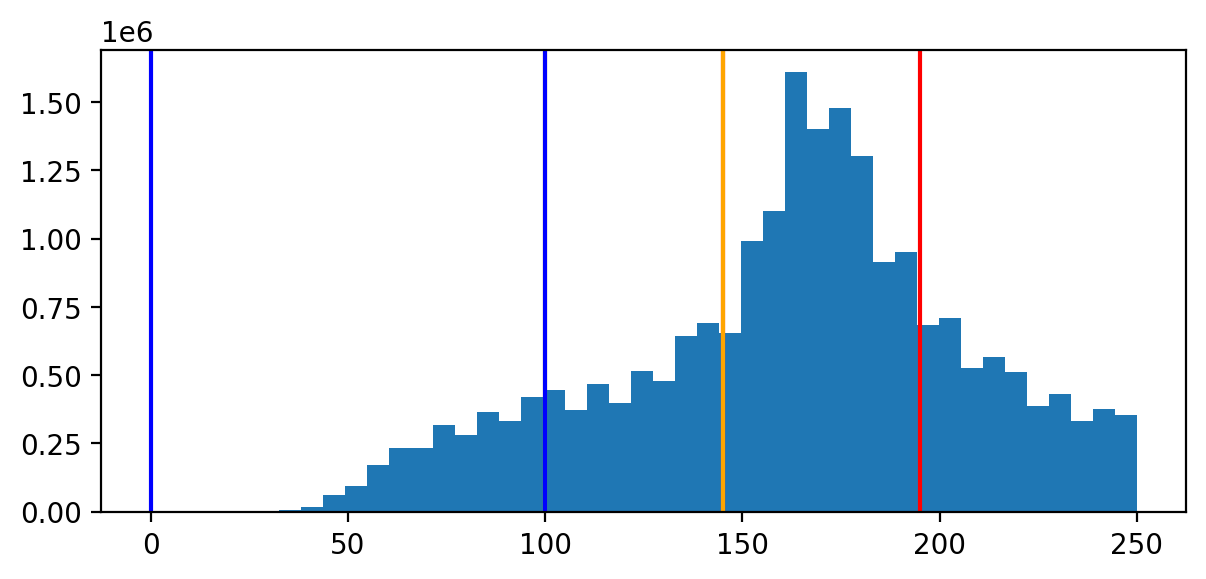

In [5]:
chromatin_metrics.plot_len_dist()

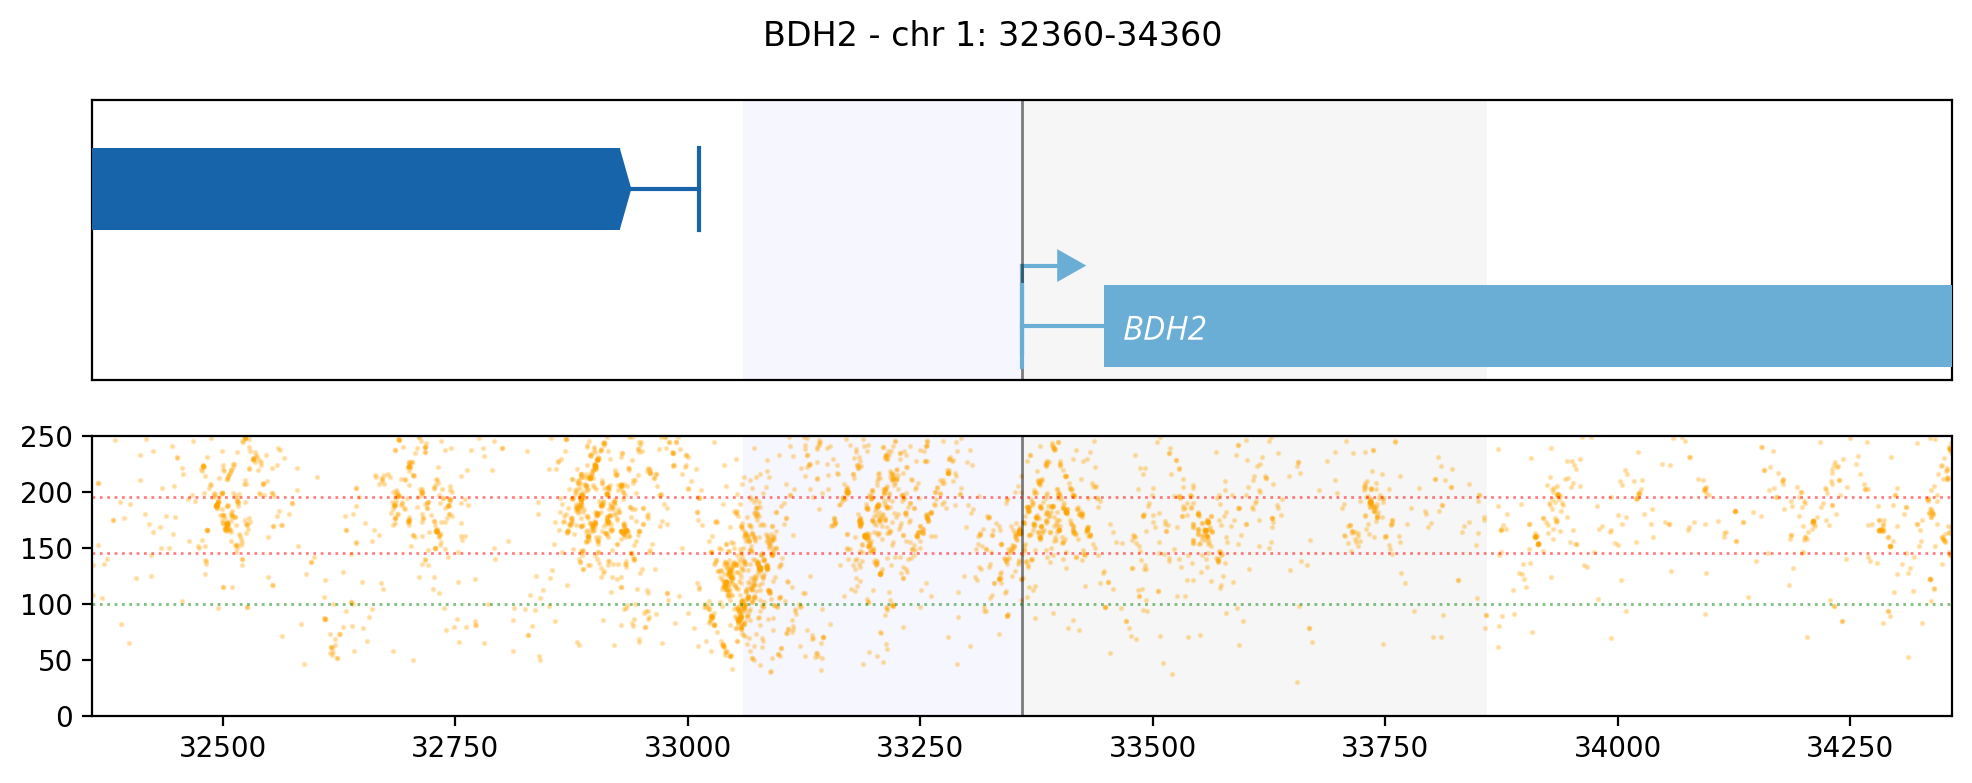

In [7]:
# Example plot of a gene and its counts
chromatin_metrics.set_chrom(1)
gene = chromatin_metrics.chrom_genes.iloc[10]
chromatin_metrics.plot_mnase_gene(gene)

In [12]:
from src.timer import Timer
from cc_src.read_bam import read_mnase_bam
from cc_src.mnase_reads import save_mnase_reads

def save_gene_chrom_reads(replicate_filenames, replicate):
    # Gene counts for all time points
    all_fragments = pd.DataFrame()
    chroms = range(1, 17)

    # Timer initialization
    timer = Timer()
    timer.start()

    for chrom in range(1, 17):

        print(f"Creating MNase-seq file for chromosome {chrom}")
        chrom_reads = pd.DataFrame()

        # Iterate through each bam file/timepoint
        for timepoint, filename in replicate_filenames:

            print(f"Load MNase-seq for time point {timepoint}, the filepath is: {filename}")

            mnase_reads = read_mnase_bam(filename, sample=timepoint, timer=timer,
                                         chroms=[chrom])
            chrom_reads = pd.concat([chrom_reads, mnase_reads])

        save_mnase_reads(chrom_reads, chrom, replicate)
        print(f"\nDone...Elapsed time: {timer.get_time()}")

    print(f"Completed in {timer.get_time()}")


In [10]:
# Let's store the MNase-seq into a pandas dataframe for quicker read access for plotting.
replicate1_filenames = [
    (0, '../_archive/data/bam/cell_cycle/mnase/DMAH64_MNase_rep1_0_min.bam'),
    (10, '../_archive/data/bam/cell_cycle/mnase/DMAH65_MNase_rep1_10_min.bam'),
    (20, '../_archive/data/bam/cell_cycle/mnase/DMAH66_MNase_rep1_20_min.bam'),
    (30, '../_archive/data/bam/cell_cycle/mnase/DMAH67_MNase_rep1_30_min.bam'),
    (40, '../_archive/data/bam/cell_cycle/mnase/DMAH68_MNase_rep1_40_min.bam'),
    (50, '../_archive/data/bam/cell_cycle/mnase/DMAH69_MNase_rep1_50_min.bam'),
    (60, '../_archive/data/bam/cell_cycle/mnase/DMAH70_MNase_rep1_60_min.bam'),
    (70, '../_archive/data/bam/cell_cycle/mnase/DMAH71_MNase_rep1_70_min.bam'),
    (80, '../_archive/data/bam/cell_cycle/mnase/DMAH72_MNase_rep1_80_min.bam'),
    (90, '../_archive/data/bam/cell_cycle/mnase/DMAH73_MNase_rep1_90_min.bam'),
    (100, '../_archive/data/bam/cell_cycle/mnase/DMAH74_MNase_rep1_100_min.bam'),
    (110, '../_archive/data/bam/cell_cycle/mnase/DMAH75_MNase_rep1_110_min.bam'),
    (120, '../_archive/data/bam/cell_cycle/mnase/DMAH76_MNase_rep1_120_min.bam'),
    (130, '../_archive/data/bam/cell_cycle/mnase/DMAH77_MNase_rep1_130_min.bam'),
    (140, '../_archive/data/bam/cell_cycle/mnase/DMAH78_MNase_rep1_140_min.bam'),
    (150, '../_archive/data/bam/cell_cycle/mnase/DMAH79_MNase_rep1_150_min.bam')]


replicate2_filenames = [(0, '../_archive/data/bam/cell_cycle/mnase/DMAH82_MNase_rep2_0_min.bam'),
                         (10, '../_archive/data/bam/cell_cycle/mnase/DMAH83_MNase_rep2_10_min.bam'),
                         (20, '../_archive/data/bam/cell_cycle/mnase/DMAH84_MNase_rep2_20_min.bam'),
                         (30, '../_archive/data/bam/cell_cycle/mnase/DMAH85_MNase_rep2_30_min.bam'),
                         (40, '../_archive/data/bam/cell_cycle/mnase/DMAH86_MNase_rep2_40_min.bam'),
                         (50, '../_archive/data/bam/cell_cycle/mnase/DMAH87_MNase_rep2_50_min.bam'),
                         (60, '../_archive/data/bam/cell_cycle/mnase/DMAH88_MNase_rep2_60_min.bam'),
                         (70, '../_archive/data/bam/cell_cycle/mnase/DMAH89_MNase_rep2_70_min.bam'),
                         (80, '../_archive/data/bam/cell_cycle/mnase/DMAH90_MNase_rep2_80_min.bam'),
                         (90, '../_archive/data/bam/cell_cycle/mnase/DMAH91_MNase_rep2_90_min.bam'),
                         (100, '../_archive/data/bam/cell_cycle/mnase/DMAH92_MNase_rep2_100_min.bam'),
                         (110, '../_archive/data/bam/cell_cycle/mnase/DMAH93_MNase_rep2_110_min.bam'),
                         (120, '../_archive/data/bam/cell_cycle/mnase/DMAH94_MNase_rep2_120_min.bam'),
                         (130, '../_archive/data/bam/cell_cycle/mnase/DMAH95_MNase_rep2_130_min.bam'),
                         (140, '../_archive/data/bam/cell_cycle/mnase/DMAH96_MNase_rep2_140_min.bam')]

In [ ]:
save_gene_chrom_reads(replicate1_filenames, 2)

In [13]:
save_gene_chrom_reads(replicate1_filenames, 1)


Creating MNase-seq file for chromosome 1
Load MNase-seq for time point 0, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH64_MNase_rep1_0_min.bam
Load MNase-seq for time point 10, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH65_MNase_rep1_10_min.bam
Load MNase-seq for time point 20, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH66_MNase_rep1_20_min.bam
Load MNase-seq for time point 30, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH67_MNase_rep1_30_min.bam
Load MNase-seq for time point 40, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH68_MNase_rep1_40_min.bam
Load MNase-seq for time point 50, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH69_MNase_rep1_50_min.bam
Load MNase-seq for time point 60, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH70_MNase_rep1_60_min.bam
Load MNase-seq for time point 70, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH71_MNase_rep1_70_min.bam
Load MNase-seq fo

Load MNase-seq for time point 10, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH65_MNase_rep1_10_min.bam
Load MNase-seq for time point 20, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH66_MNase_rep1_20_min.bam
Load MNase-seq for time point 30, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH67_MNase_rep1_30_min.bam
Load MNase-seq for time point 40, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH68_MNase_rep1_40_min.bam
Load MNase-seq for time point 50, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH69_MNase_rep1_50_min.bam
Load MNase-seq for time point 60, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH70_MNase_rep1_60_min.bam
Load MNase-seq for time point 70, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH71_MNase_rep1_70_min.bam
Load MNase-seq for time point 80, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH72_MNase_rep1_80_min.bam
Load MNase-seq for time point 90, the filepath is: ../_a

Load MNase-seq for time point 10, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH65_MNase_rep1_10_min.bam
Load MNase-seq for time point 20, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH66_MNase_rep1_20_min.bam
Load MNase-seq for time point 30, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH67_MNase_rep1_30_min.bam
Load MNase-seq for time point 40, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH68_MNase_rep1_40_min.bam
Load MNase-seq for time point 50, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH69_MNase_rep1_50_min.bam
Load MNase-seq for time point 60, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH70_MNase_rep1_60_min.bam
Load MNase-seq for time point 70, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH71_MNase_rep1_70_min.bam
Load MNase-seq for time point 80, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH72_MNase_rep1_80_min.bam
Load MNase-seq for time point 90, the filepath is: ../_a

Load MNase-seq for time point 10, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH65_MNase_rep1_10_min.bam
Load MNase-seq for time point 20, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH66_MNase_rep1_20_min.bam
Load MNase-seq for time point 30, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH67_MNase_rep1_30_min.bam
Load MNase-seq for time point 40, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH68_MNase_rep1_40_min.bam
Load MNase-seq for time point 50, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH69_MNase_rep1_50_min.bam
Load MNase-seq for time point 60, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH70_MNase_rep1_60_min.bam
Load MNase-seq for time point 70, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH71_MNase_rep1_70_min.bam
Load MNase-seq for time point 80, the filepath is: ../_archive/data/bam/cell_cycle/mnase/DMAH72_MNase_rep1_80_min.bam
Load MNase-seq for time point 90, the filepath is: ../_a